In [1]:
# All paths in this notebook are relative to the repository root; anchor the working directory there
import os
while not os.path.exists('METHODOLOGY.md') and os.getcwd() != '/': os.chdir('..')
assert os.path.exists('METHODOLOGY.md'), 'run from inside the Nofit_LRT_Extension repository'

# PCA — Car vs Transit Destination Structure in the Survey

The PCA suites so far compared the *survey* with the *cellular* matrix. This notebook applies the same tests **within the survey**, with the mode group as the grouping: do car trips and transit trips share the same destination-choice structure, and where do they diverge? The question matters for the LRT because a transit matrix that is only a scaled-down car matrix would say the LRT market can be read off the car pattern; a transit matrix with its own structure says where transit demand concentrates today, and that is where a new line competes.

**Data.** The 2017 trips file, AM 06:00–09:00, both trip ends in the study area, weighted (`new_wf`), exactly the extraction of step 15. Mode groups: **car** = `mainmode` 10 / 11; **transit** = bus (3, 4) + taxi-type (5, 8) + rail (7); **bus** (3, 4) alone as a sensitivity. Zone conversion by the population / employment split of step 15 (no cellular data). Levels: 36 superzones (primary) and the 28 sub-areas around the corridor; the TAZ level is too sparse for transit (≈ 820 sampled transit trips per day over 778 zones).

**Design.** Origins are observations, row-normalised destination-share profiles are features (as in the earlier suites). Each statistic for *car vs transit* is judged against two references: the **car day 1 vs day 2** and the **transit day 1 vs day 2** repeatability (the same households on two days, so a repeatability reference, not a ceiling), and a **permuted-geography null**. Because transit rows are thin (median ≈ 30 sampled trips per origin superzone over two days), the main comparison pools both days, a **household bootstrap** (200 replicates) gives the sampling range of the overlap, and a restricted run keeps only origins with at least 20 sampled transit trips.

| # | Test | Statistic |
|---|---|---|
| T1 | Dimensionality | scree, n₈₀, participation ratio |
| T2 | Subspace overlap | mean cos² of principal angles, car vs transit; permuted-geography null; household bootstrap |
| T3 | Cross-projection | RCEV(k): transit variance captured by car components and vice versa |
| T4 | Component matching | Tucker congruence, Hungarian-matched; interpretation of the leading components |
| T5 | Divergence map | joint PCA displacement; sign-flip test for a common direction |
| T6 | Divergence anatomy | diagonal share of ‖transit − car‖²; diagonal ablation; the difference matrix by destination |

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.linalg import subspace_angles
from scipy.optimize import linear_sum_assignment
rng = np.random.default_rng(42)
BLUE, ORANGE, AQUA, PURPLE = '#2a78d6', '#eb6834', '#1baf7a', '#7b5bd6'
INK, INK2, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#fcfcfb', '#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b'])
CMAP_DIV = LinearSegmentedColormap.from_list('div', ['#0d366b', '#2a78d6', '#86b6ef', '#f0efec', '#f2a29e', '#e34948', '#7f1e1e'])
def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    for s in ax.spines.values(): s.set_color(AXIS)
    ax.tick_params(colors=INK2, labelsize=9)
    if title: ax.set_title(title, color=INK, fontsize=12)
    if xlabel: ax.set_xlabel(xlabel, color=INK2, fontsize=10)
    if ylabel: ax.set_ylabel(ylabel, color=INK2, fontsize=10)
OUT = 'Output/ths2017/tests'; os.makedirs(OUT, exist_ok=True); os.makedirs('Output/figures', exist_ok=True)
def save_show(fig, name): fig.savefig(f'Output/figures/{name}', dpi=150, bbox_inches='tight', facecolor='white'); plt.show()

# ---- trips (step-15 extraction) ----
df = pd.read_excel('Input/trips_ths_2017.xlsx')
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy(); g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1); d['trip_dep_h'] = g['Dep_h'].shift(1)
trips = d.dropna(subset=['origin', 'actTaz', 'trip_dep_h']); trips = trips[trips['trip_dep_h'].isin([6, 7, 8])].copy()
GROUP = {'car': [10, 11], 'transit': [3, 4, 5, 8, 7], 'bus': [3, 4]}
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636'); map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']
trips['o1250'] = trips['origin'].map(map_2636_1250); trips['d1250'] = trips['actTaz'].map(map_2636_1250)
KEYS_LFS = 'Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv'
keys_raw = pd.read_csv('Input/taz_keys_from_shapefile.csv') if open(KEYS_LFS, 'rb').read(40).startswith(b'version https://git-lfs') else pd.read_csv(KEYS_LFS, encoding='windows-1255')
kd = keys_raw[['TAZ_1270', 'TAZ_NUMBER', 'SZ_NEW']].dropna(subset=['TAZ_NUMBER']).astype({'TAZ_NUMBER': int, 'SZ_NEW': int}).drop_duplicates('TAZ_NUMBER')
TAZ = np.array(sorted(kd['TAZ_NUMBER'])); N = len(TAZ); taz_pos = {t: i for i, t in enumerate(TAZ)}
sz_of = kd.set_index('TAZ_NUMBER')['SZ_NEW'].reindex(TAZ).values; SZ = sorted(set(sz_of)); sz_pos = {z: i for i, z in enumerate(SZ)}
children = kd.groupby('TAZ_1270')['TAZ_NUMBER'].apply(list); north_1250 = sorted(children.index); z_idx = {z: i for i, z in enumerate(north_1250)}
tm = trips[trips['o1250'].isin(z_idx) & trips['d1250'].isin(z_idx)].copy(); tm['oi'] = tm['o1250'].map(z_idx); tm['di'] = tm['d1250'].map(z_idx)
zon = pd.read_csv('Input/Zonal_2020.csv', encoding='windows-1255').set_index('TAZ_ID').reindex(TAZ)
pop, emp = zon['POPULATION'].fillna(0).values, zon['EMPL_TOT'].fillna(0).values
def alloc(primary, secondary):
    S = np.zeros((len(north_1250), N))
    for z, kids in children.items():
        idx = [taz_pos[t] for t in kids]
        for v in (primary[idx], secondary[idx], np.ones(len(idx))):
            if v.sum() > 0: S[z_idx[z], idx] = v / v.sum(); break
    return S
S_o, S_d = alloc(pop, emp), alloc(emp, pop)
M_sz = np.zeros((N, len(SZ))); M_sz[np.arange(N), [sz_pos[z] for z in sz_of]] = 1
sub_key = pd.read_excel('Input/Submatrix_tazs.xlsx'); area_of = sub_key.set_index('TAZ')['AggAreaCode']; AREA = sorted(area_of.unique())
M_area = np.zeros((N, len(AREA))); apos = {a: i for i, a in enumerate(AREA)}
for i, t in enumerate(TAZ):
    if t in area_of.index: M_area[i, apos[area_of[t]]] = 1
legend = pd.read_csv('Output/ths2017/study_taz/submatrices/area_legend.csv').set_index('AggAreaCode'); area_names = legend['AggAreaName']
sz_loc = pd.read_csv('Input/sz_localities.csv').set_index('SZ_NEW')['main localities']
Z_SZ, Z_AREA = S_o @ M_sz, S_o @ M_area                     # 1250 -> SZ / area on the origin side
D_SZ, D_AREA = S_d @ M_sz, S_d @ M_area                     # on the destination side

def counts(sub, Zo, Zd, w=None):
    # weighted OD matrix at the aggregate level from a subset of trips
    w = sub['new_wf'].values if w is None else w
    M = np.zeros((len(north_1250),) * 2); np.add.at(M, (sub['oi'].values, sub['di'].values), w)
    return Zo.T @ M @ Zd
def rownorm(M):
    rs = M.sum(axis=1, keepdims=True); return np.divide(M, rs, out=np.zeros_like(M), where=rs > 0)
def n_by_origin(sub, Zo):
    n = np.zeros(len(north_1250)); np.add.at(n, sub['oi'].values, 1); return Zo.T @ n   # sampled-trip equivalents per origin zone

SETS = {}
for grp, codes in GROUP.items():
    sub = tm[tm['mainmode'].isin(codes)]
    for day in (1, 2, 'pooled'):
        s = sub if day == 'pooled' else sub[sub['SurveyDay'] == day]
        SETS[(grp, day)] = {'sz': counts(s, Z_SZ, D_SZ), 'area': counts(s, Z_AREA, D_AREA), 'n_sz': n_by_origin(s, Z_SZ), 'n_area': n_by_origin(s, Z_AREA), 'sampled': len(s)}
print("sampled AM trips (both ends in the study area):", {k: v['sampled'] for k, v in SETS.items() if k[1] == 'pooled'})
print(f"sampled transit trips per origin superzone (2 days): median {np.median(SETS[('transit', 'pooled')]['n_sz']):.0f}, min {SETS[('transit', 'pooled')]['n_sz'].min():.0f}, max {SETS[('transit', 'pooled')]['n_sz'].max():.0f}; origins with >= 20: {(SETS[('transit', 'pooled')]['n_sz'] >= 20).sum()} of {len(SZ)}")

sampled AM trips (both ends in the study area): {('car', 'pooled'): 15949, ('transit', 'pooled'): 1943, ('bus', 'pooled'): 1636}
sampled transit trips per origin superzone (2 days): median 36, min 2, max 192; origins with >= 20: 26 of 36


## 1. Profiles and PCA machinery

In [3]:
def pca(P):
    X = np.asarray(P, float); Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False); lam = s ** 2 / max(X.shape[0] - 1, 1)
    return {'V': Vt.T, 'lam': lam, 'evr': lam / lam.sum(), 'scores': U * s}
def n_comp(evr, thr): return int(np.searchsorted(np.cumsum(evr), thr) + 1)
def part_ratio(lam): return float(lam.sum() ** 2 / (lam ** 2).sum())
def mean_cos2(Va, Vb, k): return float(np.mean(np.cos(subspace_angles(Va[:, :k], Vb[:, :k])) ** 2))
def rcev(P_target, pc_target, pc_source, k):
    Xc = np.asarray(P_target, float) - np.asarray(P_target, float).mean(axis=0)
    cap = ((Xc @ pc_source['V'][:, :k]) ** 2).sum() / max(Xc.shape[0] - 1, 1); return float(cap / pc_target['lam'][:k].sum())

def level_profiles(level, min_n_transit=1):
    # row-normalised profiles for car / transit / bus (pooled, d1, d2) on the origins that have trips in every set and >= min_n_transit sampled transit trips
    key = 'sz' if level == 'SZ' else 'area'
    ok = np.ones(SETS[('car', 'pooled')][key].shape[0], bool)
    for k_, v in SETS.items(): ok &= v[key].sum(axis=1) > 0
    ok &= SETS[('transit', 'pooled')]['n_' + key] >= min_n_transit
    P = {k_: rownorm(v[key])[ok] for k_, v in SETS.items()}
    return P, ok
P_SZ, ok_sz = level_profiles('SZ'); P_AREA, ok_area = level_profiles('AREA')
PC_SZ = {k_: pca(v) for k_, v in P_SZ.items()}; PC_AREA = {k_: pca(v) for k_, v in P_AREA.items()}
print(f"origins used: SZ {ok_sz.sum()} of {len(SZ)}; areas {ok_area.sum()} of {len(AREA)}")

origins used: SZ 35 of 36; areas 16 of 28


## 2. T1 — Dimensionality

In [4]:
rows = []
for lvl, PC in [('SZ', PC_SZ), ('AREA', PC_AREA)]:
    for key in [('car', 'pooled'), ('transit', 'pooled'), ('bus', 'pooled'), ('car', 1), ('car', 2), ('transit', 1), ('transit', 2)]:
        pc = PC[key]; rows.append({'level': lvl, 'matrix': f'{key[0]} {key[1]}', 'PC1 share': pc['evr'][0], 'n80': n_comp(pc['evr'], .8), 'n90': n_comp(pc['evr'], .9), 'participation ratio': part_ratio(pc['lam'])})
t1 = pd.DataFrame(rows)
kSZ = n_comp(PC_SZ[('car', 'pooled')]['evr'], .8); kAREA = n_comp(PC_AREA[('car', 'pooled')]['evr'], .8)
print(f"headline subspace dimension (80 % of car variance): k = {kSZ} at SZ, k = {kAREA} on the sub-areas")
t1.round(3)

headline subspace dimension (80 % of car variance): k = 20 at SZ, k = 6 on the sub-areas


,level,matrix,PC1 share,n80,n90,participation ratio
0,SZ,car pooled,0.067,20,24,25.325
1,SZ,transit pooled,0.116,14,18,17.021
2,SZ,bus pooled,0.113,14,18,17.674
3,SZ,car 1,0.067,20,24,25.295
4,SZ,car 2,0.067,20,24,25.263
5,SZ,transit 1,0.106,14,18,17.603
6,SZ,transit 2,0.118,13,18,16.489
7,AREA,car pooled,0.201,6,8,7.580
8,AREA,transit pooled,0.219,6,8,7.225
9,AREA,bus pooled,0.227,6,8,7.259


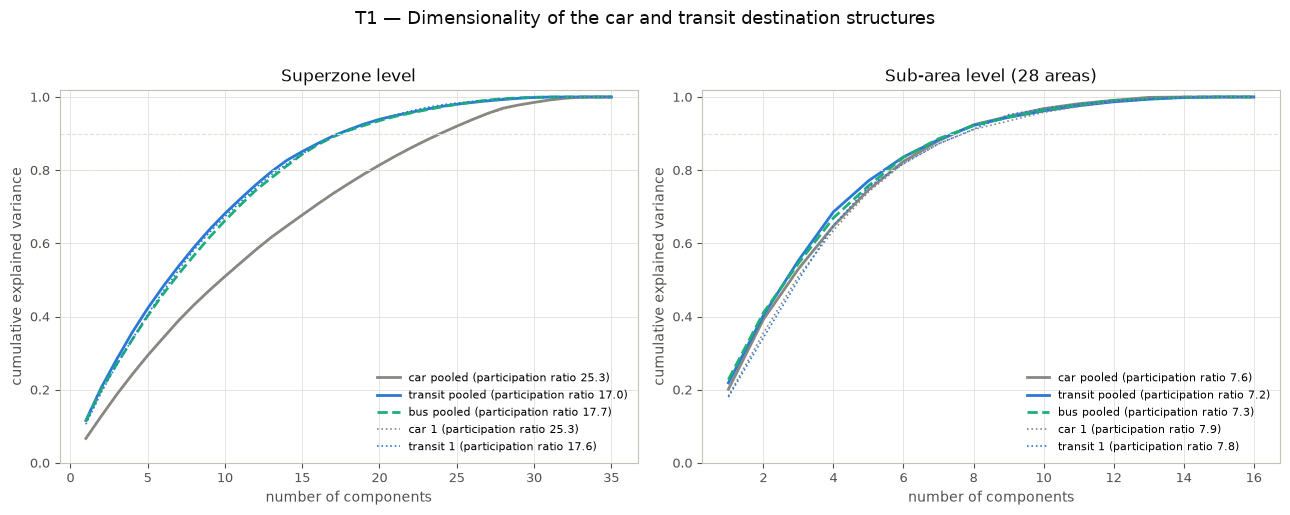

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')
for ax, (title, PC, pmax) in zip(axes, [('Superzone level', PC_SZ, 36), ('Sub-area level (28 areas)', PC_AREA, 28)]):
    for key, color, ls in [(('car', 'pooled'), MUTED, '-'), (('transit', 'pooled'), BLUE, '-'), (('bus', 'pooled'), AQUA, '--'), (('car', 1), MUTED, ':'), (('transit', 1), BLUE, ':')]:
        cum = np.cumsum(PC[key]['evr'])[:pmax]
        ax.plot(range(1, len(cum) + 1), cum, color=color, linewidth=2 if key[1] == 'pooled' else 1.2, linestyle=ls, label=f"{key[0]} {key[1]} (participation ratio {part_ratio(PC[key]['lam']):.1f})")
    for thr in (0.8, 0.9): ax.axhline(thr, color=GRID, linewidth=0.8, linestyle='--')
    ax.set_ylim(0, 1.02); style_ax(ax, title, 'number of components', 'cumulative explained variance'); ax.legend(frameon=False, loc='lower right', fontsize=8)
fig.suptitle('T1 — Dimensionality of the car and transit destination structures', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); save_show(fig, 'pca_cvt_scree.png')

## 3. T2 — Subspace overlap: car vs transit against each mode's own repeatability and a permuted-geography null

In [6]:
def overlap_table(PC, P, ks, khead, lvl):
    rows = []
    for k in ks:
        rows.append({'level': lvl, 'k': k,
                     'car vs transit (pooled)': mean_cos2(PC[('car', 'pooled')]['V'], PC[('transit', 'pooled')]['V'], k),
                     'car vs bus (pooled)': mean_cos2(PC[('car', 'pooled')]['V'], PC[('bus', 'pooled')]['V'], k),
                     'car d1 vs car d2': mean_cos2(PC[('car', 1)]['V'], PC[('car', 2)]['V'], k),
                     'transit d1 vs transit d2': mean_cos2(PC[('transit', 1)]['V'], PC[('transit', 2)]['V'], k),
                     'car d1 vs transit d2 (cross-day, cross-mode)': mean_cos2(PC[('car', 1)]['V'], PC[('transit', 2)]['V'], k),
                     'chance k/p': k / P[('car', 'pooled')].shape[1]})
    return pd.DataFrame(rows)
ov_sz = overlap_table(PC_SZ, P_SZ, range(1, 17), kSZ, 'SZ'); ov_area = overlap_table(PC_AREA, P_AREA, range(1, 15), kAREA, 'AREA')
ov = pd.concat([ov_sz, ov_area]); ov.to_csv(f'{OUT}/pca_car_vs_transit_overlap.csv', index=False, float_format='%.4f')

def perm_null(Va, Vb, k, n_perm, seed=0):
    r = np.random.default_rng(seed); p = Va.shape[0]
    return np.array([mean_cos2(Va[r.permutation(p)], Vb, k) for _ in range(n_perm)])
perm = {}
for lvl, PC, k in [('SZ', PC_SZ, kSZ), ('AREA', PC_AREA, kAREA)]:
    null = perm_null(PC[('car', 'pooled')]['V'], PC[('transit', 'pooled')]['V'], k, 2000)
    obs = mean_cos2(PC[('car', 'pooled')]['V'], PC[('transit', 'pooled')]['V'], k)
    perm[lvl] = dict(null=null, obs=obs, p=(1 + (null >= obs).sum()) / (1 + len(null)), k=k,
                     car_rep=mean_cos2(PC[('car', 1)]['V'], PC[('car', 2)]['V'], k), tr_rep=mean_cos2(PC[('transit', 1)]['V'], PC[('transit', 2)]['V'], k))
    print(f"{lvl} (k = {k}): car vs transit {obs:.3f} | car day-to-day {perm[lvl]['car_rep']:.3f} | transit day-to-day {perm[lvl]['tr_rep']:.3f} | null mean {null.mean():.3f}, max {null.max():.3f}, p = {perm[lvl]['p']:.4f}")

# household bootstrap of the pooled car-vs-transit overlap (SZ)
def profiles_from_mult(grp, mult_by_hh, level_Z, level_D, ok):
    sub = tm[tm['mainmode'].isin(GROUP[grp])]; w = sub['new_wf'].values * mult_by_hh.reindex(sub['HHID3'].values).fillna(0).values
    return rownorm(counts(sub, level_Z, level_D, w))[ok]
hh_ids = tm['HHID3'].unique(); boot = []
for b in range(200):
    mult = pd.Series(np.bincount(rng.integers(0, len(hh_ids), len(hh_ids)), minlength=len(hh_ids)), index=hh_ids)
    Pc = profiles_from_mult('car', mult, Z_SZ, D_SZ, ok_sz); Pt = profiles_from_mult('transit', mult, Z_SZ, D_SZ, ok_sz)
    good = (Pc.sum(axis=1) > 0) & (Pt.sum(axis=1) > 0)
    boot.append(mean_cos2(pca(Pc[good])['V'], pca(Pt[good])['V'], kSZ))
boot = np.array(boot); print(f"SZ household bootstrap of car-vs-transit overlap (k = {kSZ}): median {np.median(boot):.3f}, 5–95 % {np.percentile(boot, 5):.3f}–{np.percentile(boot, 95):.3f}")

# restricted run: origins with >= 20 sampled transit trips
P_SZr, ok_r = level_profiles('SZ', min_n_transit=20); PC_SZr = {k_: pca(v) for k_, v in P_SZr.items()}
kr = min(kSZ, ok_r.sum() - 2)
print(f"restricted to {ok_r.sum()} origins with >= 20 sampled transit trips (k = {kr}): car vs transit {mean_cos2(PC_SZr[('car', 'pooled')]['V'], PC_SZr[('transit', 'pooled')]['V'], kr):.3f}, "
      f"car day-to-day {mean_cos2(PC_SZr[('car', 1)]['V'], PC_SZr[('car', 2)]['V'], kr):.3f}, transit day-to-day {mean_cos2(PC_SZr[('transit', 1)]['V'], PC_SZr[('transit', 2)]['V'], kr):.3f}")
ov.round(3)

SZ (k = 20): car vs transit 0.749 | car day-to-day 0.951 | transit day-to-day 0.813 | null mean 0.572, max 0.697, p = 0.0005


AREA (k = 6): car vs transit 0.576 | car day-to-day 0.930 | transit day-to-day 0.598 | null mean 0.225, max 0.531, p = 0.0005


SZ household bootstrap of car-vs-transit overlap (k = 20): median 0.709, 5–95 % 0.659–0.764
restricted to 26 origins with >= 20 sampled transit trips (k = 20): car vs transit 0.834, car day-to-day 0.980, transit day-to-day 0.856


,level,k,car vs transit (pooled),car vs bus (pooled),car d1 vs car d2,transit d1 vs transit d2,"car d1 vs transit d2 (cross-day, cross-mode)",chance k/p
0,SZ,1,0.519,0.530,0.953,0.950,0.475,0.028
1,SZ,2,0.583,0.529,0.961,0.855,0.490,0.056
2,SZ,3,0.516,0.477,0.938,0.621,0.354,0.083
3,SZ,4,0.441,0.433,0.960,0.507,0.293,0.111
4,SZ,5,0.503,0.469,0.984,0.712,0.461,0.139
5,SZ,6,0.442,0.510,0.837,0.755,0.458,0.167
6,SZ,7,0.506,0.538,0.978,0.697,0.504,0.194
7,SZ,8,0.595,0.561,0.970,0.718,0.567,0.222
8,SZ,9,0.616,0.601,0.915,0.764,0.550,0.250
9,SZ,10,0.616,0.603,0.883,0.748,0.507,0.278


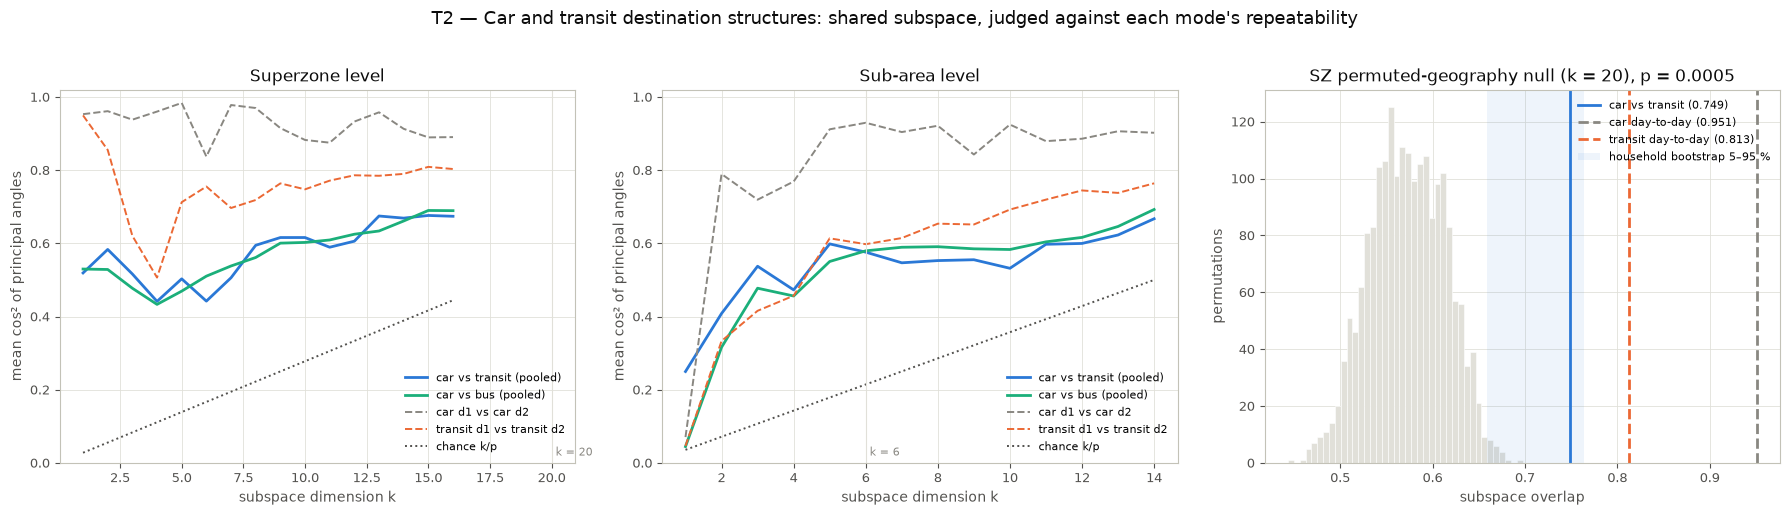

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')
for ax, (title, o, khead, p) in zip(axes[:2], [('Superzone level', ov_sz, kSZ, ok_sz.sum()), ('Sub-area level', ov_area, kAREA, ok_area.sum())]):
    for col, color, ls in [('car vs transit (pooled)', BLUE, '-'), ('car vs bus (pooled)', AQUA, '-'), ('car d1 vs car d2', MUTED, '--'), ('transit d1 vs transit d2', ORANGE, '--'), ('chance k/p', INK2, ':')]:
        ax.plot(o['k'], o[col], color=color, linewidth=2 if ls == '-' else 1.4, linestyle=ls, label=col)
    ax.axvline(khead, color=GRID, linewidth=0.8); ax.text(khead, 0.02, f' k = {khead}', color=MUTED, fontsize=8); ax.set_ylim(0, 1.02)
    style_ax(ax, title, 'subspace dimension k', 'mean cos² of principal angles'); ax.legend(frameon=False, fontsize=8, loc='lower right')
ax = axes[2]; dd = perm['SZ']
ax.hist(dd['null'], bins=40, color=GRID, edgecolor='white', linewidth=0.4)
ax.axvline(dd['obs'], color=BLUE, linewidth=2, label=f"car vs transit ({dd['obs']:.3f})")
ax.axvline(dd['car_rep'], color=MUTED, linewidth=2, linestyle='--', label=f"car day-to-day ({dd['car_rep']:.3f})")
ax.axvline(dd['tr_rep'], color=ORANGE, linewidth=2, linestyle='--', label=f"transit day-to-day ({dd['tr_rep']:.3f})")
ax.axvspan(np.percentile(boot, 5), np.percentile(boot, 95), color=BLUE, alpha=0.08, lw=0, label='household bootstrap 5–95 %')
style_ax(ax, f"SZ permuted-geography null (k = {dd['k']}), p = {dd['p']:.4f}", 'subspace overlap', 'permutations'); ax.legend(frameon=False, fontsize=8)
fig.suptitle('T2 — Car and transit destination structures: shared subspace, judged against each mode\'s repeatability', color=INK, fontsize=13, y=1.02)
plt.tight_layout(); save_show(fig, 'pca_cvt_subspace_overlap.png')

## 4. T3 — Cross-projection (RCEV)

In [8]:
rows = []
for lvl, P, PC, k in [('SZ', P_SZ, PC_SZ, kSZ), ('AREA', P_AREA, PC_AREA, kAREA)]:
    rows.append({'level': lvl, 'k': k,
                 'transit | car PCs': rcev(P[('transit', 'pooled')], PC[('transit', 'pooled')], PC[('car', 'pooled')], k),
                 'car | transit PCs': rcev(P[('car', 'pooled')], PC[('car', 'pooled')], PC[('transit', 'pooled')], k),
                 'transit d2 | transit d1 PCs (repeatability)': rcev(P[('transit', 2)], PC[('transit', 2)], PC[('transit', 1)], k),
                 'car d2 | car d1 PCs (repeatability)': rcev(P[('car', 2)], PC[('car', 2)], PC[('car', 1)], k)})
t3 = pd.DataFrame(rows); t3.to_csv(f'{OUT}/pca_car_vs_transit_rcev.csv', index=False, float_format='%.4f'); t3.round(3)

,level,k,transit | car PCs,car | transit PCs,transit d2 | transit d1 PCs (repeatability),car d2 | car d1 PCs (repeatability)
0,SZ,20,0.860,0.855,0.889,0.989
1,AREA,6,0.641,0.673,0.706,0.963


## 5. T4 — Component matching and what the leading components mean

car PC2 <-> transit PC2: |congruence| = 0.790  (car variance share 0.06, transit 0.09)
car PC1 <-> transit PC1: |congruence| = 0.720  (car variance share 0.07, transit 0.12)
car PC3 <-> transit PC3: |congruence| = 0.538  (car variance share 0.06, transit 0.08)
car PC5 <-> transit PC4: |congruence| = 0.454  (car variance share 0.05, transit 0.07)
car PC6 <-> transit PC5: |congruence| = 0.218  (car variance share 0.05, transit 0.07)
car PC4 <-> transit PC6: |congruence| = 0.162  (car variance share 0.05, transit 0.06)
car PC1 (share 0.07): corr(score, self-containment) +0.23; corr(score, share to Haifa SZs) -0.14
car PC2 (share 0.06): corr(score, self-containment) -0.74; corr(score, share to Haifa SZs) +0.65
car PC3 (share 0.06): corr(score, self-containment) -0.12; corr(score, share to Haifa SZs) +0.14
transit PC1 (share 0.12): corr(score, self-containment) -0.06; corr(score, share to Haifa SZs) -0.38
transit PC2 (share 0.09): corr(score, self-containment) +0.77; corr(score, share to Ha

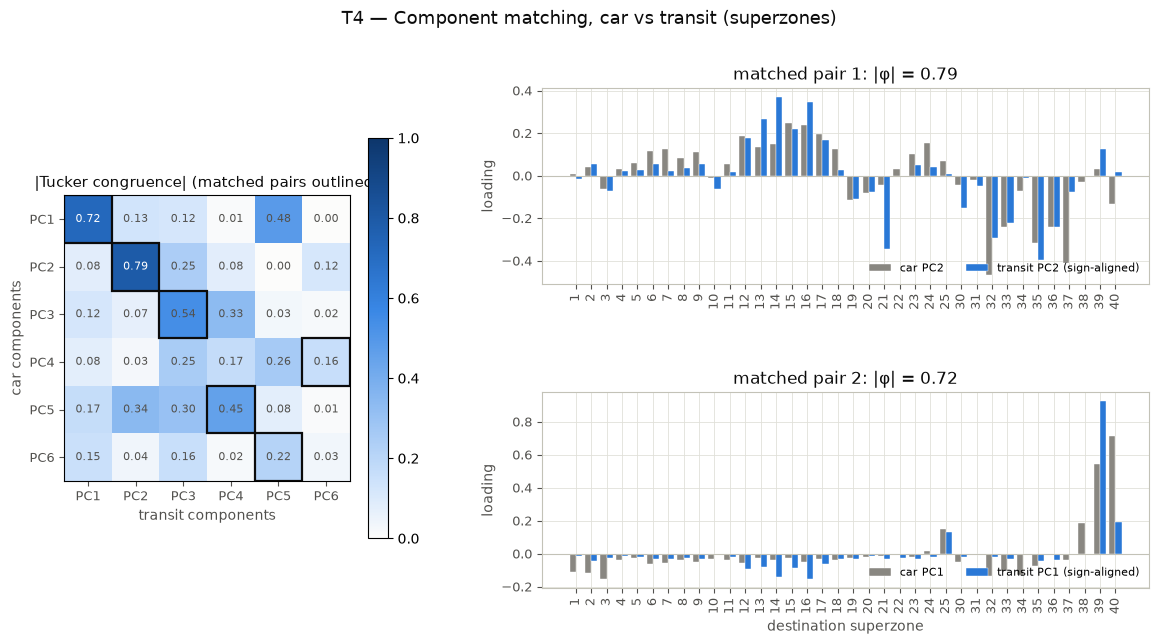

In [9]:
kc = 6
Vc, Vt = PC_SZ[('car', 'pooled')]['V'][:, :kc], PC_SZ[('transit', 'pooled')]['V'][:, :kc]
C = Vc.T @ Vt; ri, ci = linear_sum_assignment(-np.abs(C)); match = sorted(zip(ri, ci), key=lambda x: -abs(C[x[0], x[1]]))
for i, j in match: print(f"car PC{i+1} <-> transit PC{j+1}: |congruence| = {abs(C[i, j]):.3f}  (car variance share {PC_SZ[('car','pooled')]['evr'][i]:.2f}, transit {PC_SZ[('transit','pooled')]['evr'][j]:.2f})")
sz_ids = np.array(SZ)[ok_sz]
# interpretation: correlation of component scores with self-containment and with the share of trips to the Haifa superzones
HAIFA = [12, 13, 14, 15, 16, 17, 18]; hcols = [i for i, z in enumerate(SZ) if z in HAIFA]
for key in [('car', 'pooled'), ('transit', 'pooled')]:
    P, pc = P_SZ[key], PC_SZ[key]; selfc = np.diag(P) if P.shape[0] == P.shape[1] else np.array([P[i, np.where(np.array(SZ) == z)[0][0]] for i, z in enumerate(sz_ids)])
    haifa = P[:, hcols].sum(axis=1)
    for j in range(3):
        print(f"{key[0]} PC{j+1} (share {pc['evr'][j]:.2f}): corr(score, self-containment) {np.corrcoef(pc['scores'][:, j], selfc)[0,1]:+.2f}; corr(score, share to Haifa SZs) {np.corrcoef(pc['scores'][:, j], haifa)[0,1]:+.2f}")

fig = plt.figure(figsize=(14, 6.5), facecolor='white'); gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.7], hspace=0.55, wspace=0.25)
ax = fig.add_subplot(gs[:, 0]); im = ax.imshow(np.abs(C), cmap=CMAP_SEQ, vmin=0, vmax=1)
for i in range(kc):
    for j in range(kc):
        v = abs(C[i, j]); ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color='white' if v > 0.55 else INK2)
for i, j in zip(ri, ci): ax.add_patch(plt.Rectangle((j - .5, i - .5), 1, 1, fill=False, edgecolor=INK, linewidth=1.6))
ax.set_xticks(range(kc), [f'PC{j+1}' for j in range(kc)]); ax.set_yticks(range(kc), [f'PC{i+1}' for i in range(kc)])
ax.set_xlabel('transit components', color=INK2); ax.set_ylabel('car components', color=INK2); ax.set_title('|Tucker congruence| (matched pairs outlined)', color=INK, fontsize=11); ax.tick_params(colors=INK2, labelsize=9); fig.colorbar(im, ax=ax, shrink=0.8)
x = np.arange(len(SZ))
for row, (i, j) in enumerate(match[:2]):
    ax = fig.add_subplot(gs[row, 1]); sgn = np.sign(C[i, j])
    ax.bar(x - 0.2, Vc[:, i], width=0.4, color=MUTED, edgecolor='white', linewidth=0.3, label=f'car PC{i+1}')
    ax.bar(x + 0.2, sgn * Vt[:, j], width=0.4, color=BLUE, edgecolor='white', linewidth=0.3, label=f'transit PC{j+1} (sign-aligned)')
    ax.set_xticks(x, SZ, fontsize=6.5, rotation=90); style_ax(ax, f'matched pair {row+1}: |φ| = {abs(C[i, j]):.2f}', 'destination superzone' if row == 1 else None, 'loading'); ax.axhline(0, color=AXIS, linewidth=0.8); ax.legend(frameon=False, fontsize=8, loc='lower right', ncols=2)
fig.suptitle('T4 — Component matching, car vs transit (superzones)', color=INK, fontsize=13, y=1.0)
save_show(fig, 'pca_cvt_component_match.png')

## 6. T5 / T6 — Where car and transit diverge: joint map, common direction, diagonal, and the difference matrix

In [10]:
Pc, Pt = P_SZ[('car', 'pooled')], P_SZ[('transit', 'pooled')]; Pc1, Pc2, Pt1, Pt2 = P_SZ[('car', 1)], P_SZ[('car', 2)], P_SZ[('transit', 1)], P_SZ[('transit', 2)]
n = Pc.shape[0]; pcJ = pca(np.vstack([Pc, Pt])); sc_c, sc_t = pcJ['scores'][:n], pcJ['scores'][n:]
disp = np.linalg.norm(Pt - Pc, axis=1); disp_car = np.linalg.norm(Pc1 - Pc2, axis=1); disp_tr = np.linalg.norm(Pt1 - Pt2, axis=1)
Dm = Pt - Pc; obs_shift = np.linalg.norm(Dm.mean(axis=0)); flips = rng.choice([-1., 1.], size=(10000, n))
null_shift = np.linalg.norm((flips[:, :, None] * Dm[None]).mean(axis=1), axis=1); p_shift = (1 + (null_shift >= obs_shift).sum()) / 10001
diag_c = np.array([Pc[i, sz_pos[z]] for i, z in enumerate(sz_ids)]); diag_t = np.array([Pt[i, sz_pos[z]] for i, z in enumerate(sz_ids)])
D_sq = (Dm ** 2).sum(); diag_share = sum(Dm[i, sz_pos[z]] ** 2 for i, z in enumerate(sz_ids)) / D_sq
haifa_c, haifa_t = Pc[:, hcols].sum(axis=1), Pt[:, hcols].sum(axis=1)
print(f"mean profile distance: transit vs car {disp.mean():.3f}; car day-to-day {disp_car.mean():.3f}; transit day-to-day {disp_tr.mean():.3f}")
print(f"mean self-containment: car {diag_c.mean():.3f}, transit {diag_t.mean():.3f}; diagonal share of squared divergence {diag_share:.3f}")
print(f"common-direction test: |mean difference| {obs_shift:.4f}, sign-flip P(null >= obs) = {p_shift:.4f}  -> {'a common shift direction exists' if p_shift < 0.05 else 'no common direction: zone-specific'}")
mean_shift = pd.Series(Dm.mean(axis=0), index=SZ).sort_values()
print("destinations gaining the most transit share relative to car (mean over origins):"); print(mean_shift.tail(6).round(3).to_string())
print("destinations losing:"); print(mean_shift.head(4).round(3).to_string())
by_origin = pd.DataFrame({'origin SZ': sz_ids, 'localities': [sz_loc.get(z, '') for z in sz_ids], 'sampled transit trips (2 days)': SETS[('transit', 'pooled')]['n_sz'][ok_sz].round(0),
                          'car self-containment': diag_c, 'transit self-containment': diag_t, 'car share to Haifa SZs': haifa_c, 'transit share to Haifa SZs': haifa_t,
                          'transit − car displacement': disp, 'car day-to-day': disp_car, 'transit day-to-day': disp_tr})
by_origin.to_csv(f'{OUT}/pca_car_vs_transit_by_origin.csv', index=False, float_format='%.4f')
print(by_origin.sort_values('transit − car displacement', ascending=False).head(10).round(2).to_string(index=False))

mean profile distance: transit vs car 0.327; car day-to-day 0.058; transit day-to-day 0.215
mean self-containment: car 0.621, transit 0.453; diagonal share of squared divergence 0.439
common-direction test: |mean difference| 0.0760, sign-flip P(null >= obs) = 0.0426  -> a common shift direction exists
destinations gaining the most transit share relative to car (mean over origins):
21    0.008
39    0.012
12    0.020
13    0.027
14    0.031
16    0.033
destinations losing:
24   -0.018
38   -0.018
37   -0.018
34   -0.016
 origin SZ                              localities  sampled transit trips (2 days)  car self-containment  transit self-containment  car share to Haifa SZs  transit share to Haifa SZs  transit − car displacement  car day-to-day  transit day-to-day
        38                      אום אל פאחם, ערערה                             2.0                  0.57                      0.00                    0.02                        0.00                        1.02            0.07  

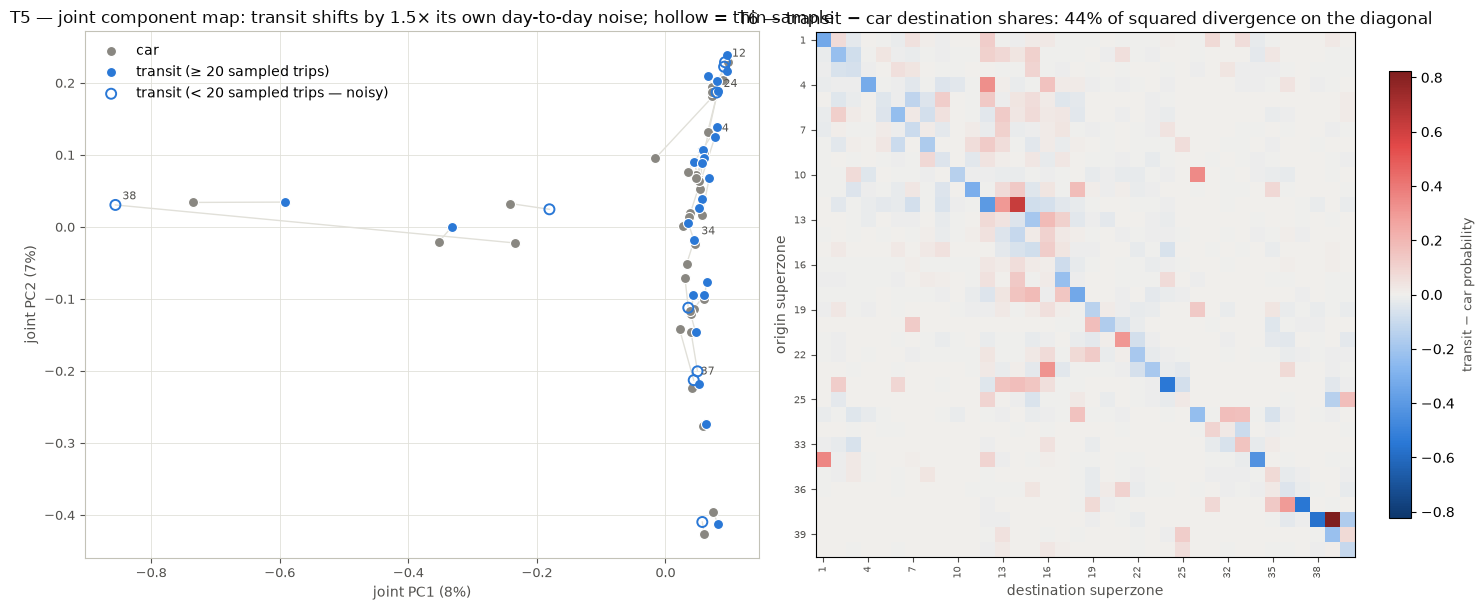

diagonal removed (35 rows, k = 20): car vs transit 0.716 (with diagonal 0.749); car day-to-day 0.865; transit day-to-day 0.787


,0,1
level,SZ,AREA
k,20,6
car vs transit overlap,0.749,0.576
bootstrap p5,0.659,NaN
bootstrap p95,0.764,NaN
car day-to-day,0.951,0.93
transit day-to-day,0.813,0.598
permutation null mean,0.572,0.225
permutation p,0.0,0.0
overlap without diagonal,0.716,NaN


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.2), facecolor='white')
ax = axes[0]
for i in range(n): ax.plot([sc_c[i, 0], sc_t[i, 0]], [sc_c[i, 1], sc_t[i, 1]], color=GRID, linewidth=1.0, zorder=1)
thin = SETS[('transit', 'pooled')]['n_sz'][ok_sz] < 20
ax.scatter(sc_c[:, 0], sc_c[:, 1], s=52, color=MUTED, edgecolors='white', linewidths=0.8, zorder=2, label='car')
ax.scatter(sc_t[~thin, 0], sc_t[~thin, 1], s=52, color=BLUE, edgecolors='white', linewidths=0.8, zorder=2, label='transit (≥ 20 sampled trips)')
ax.scatter(sc_t[thin, 0], sc_t[thin, 1], s=52, facecolors='none', edgecolors=BLUE, linewidths=1.4, zorder=2, label='transit (< 20 sampled trips — noisy)')
for i in np.argsort(-disp)[:6]: ax.annotate(str(sz_ids[i]), (sc_t[i, 0], sc_t[i, 1]), textcoords='offset points', xytext=(5, 4), fontsize=8, color=INK2)
style_ax(ax, f'T5 — joint component map: transit shifts by {disp.mean() / disp_tr.mean():.1f}× its own day-to-day noise; hollow = thin sample', f"joint PC1 ({pcJ['evr'][0]:.0%})", f"joint PC2 ({pcJ['evr'][1]:.0%})"); ax.legend(frameon=False, fontsize=10)
ax = axes[1]; vmax = np.abs(Dm).max(); im = ax.imshow(Dm, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax)
ax.set_xticks(range(0, len(SZ), 3), np.array(SZ)[::3], fontsize=7, rotation=90); ax.set_yticks(range(0, n, 3), sz_ids[::3], fontsize=7)
ax.set_xlabel('destination superzone', color=INK2); ax.set_ylabel('origin superzone', color=INK2); ax.tick_params(colors=INK2)
ax.set_title(f'T6 — transit − car destination shares: {diag_share:.0%} of squared divergence on the diagonal', color=INK, fontsize=12)
cb = fig.colorbar(im, ax=ax, shrink=0.85); cb.set_label('transit − car probability', color=INK2, fontsize=9)
plt.tight_layout(); save_show(fig, 'pca_cvt_divergence.png')

# diagonal ablation
def strip_diag_rows(P, ids):
    A = P.copy()
    for i, z in enumerate(ids): A[i, sz_pos[z]] = 0
    rs = A.sum(axis=1, keepdims=True); ok = rs[:, 0] > 0
    return np.divide(A, rs, out=np.zeros_like(A), where=rs > 0), ok
abl = {k_: strip_diag_rows(P_SZ[k_], sz_ids) for k_ in [('car', 'pooled'), ('transit', 'pooled'), ('car', 1), ('car', 2), ('transit', 1), ('transit', 2)]}
okx = np.logical_and.reduce([v[1] for v in abl.values()]); PCx = {k_: pca(v[0][okx]) for k_, v in abl.items()}
print(f"diagonal removed ({okx.sum()} rows, k = {kSZ}): car vs transit {mean_cos2(PCx[('car','pooled')]['V'], PCx[('transit','pooled')]['V'], kSZ):.3f} "
      f"(with diagonal {perm['SZ']['obs']:.3f}); car day-to-day {mean_cos2(PCx[('car',1)]['V'], PCx[('car',2)]['V'], kSZ):.3f}; transit day-to-day {mean_cos2(PCx[('transit',1)]['V'], PCx[('transit',2)]['V'], kSZ):.3f}")
summary = pd.DataFrame([{'level': 'SZ', 'k': kSZ, 'car vs transit overlap': perm['SZ']['obs'], 'bootstrap p5': np.percentile(boot, 5), 'bootstrap p95': np.percentile(boot, 95), 'car day-to-day': perm['SZ']['car_rep'], 'transit day-to-day': perm['SZ']['tr_rep'], 'permutation null mean': perm['SZ']['null'].mean(), 'permutation p': perm['SZ']['p'],
                         'overlap without diagonal': mean_cos2(PCx[('car','pooled')]['V'], PCx[('transit','pooled')]['V'], kSZ), 'mean self-containment car': diag_c.mean(), 'mean self-containment transit': diag_t.mean(), 'diagonal share of divergence': diag_share, 'common-direction p': p_shift, 'displacement ratio (vs transit day-to-day)': disp.mean() / disp_tr.mean()},
                        {'level': 'AREA', 'k': kAREA, 'car vs transit overlap': perm['AREA']['obs'], 'car day-to-day': perm['AREA']['car_rep'], 'transit day-to-day': perm['AREA']['tr_rep'], 'permutation null mean': perm['AREA']['null'].mean(), 'permutation p': perm['AREA']['p']}])
summary.to_csv(f'{OUT}/pca_car_vs_transit_summary.csv', index=False, float_format='%.4f'); summary.round(3).T

## Findings

Superzone level, k = 20 (80 % of the car variance; the car profile is flat — participation ratio 25 of 35 origins — so k is high), 35 origins:

| Statistic | Car vs transit | Car day-to-day | Transit day-to-day | Chance |
|---|---|---|---|---|
| Subspace overlap (T2) | **0.75** (household bootstrap 0.66–0.76; permutation p = 0.0005, null max 0.70) | 0.95 | 0.81 | 0.57 |
| … on the 26 origins with ≥ 20 sampled transit trips | **0.83** | 0.98 | 0.86 | |
| RCEV: transit variance captured by car components (T3) | **0.86** | 0.99 (car by car) | 0.89 (transit by transit) | |
| Leading-pair congruences (T4) | PC1 ↔ PC1 0.72, PC2 ↔ PC2 0.79 | | | |
| Mean self-containment (T6) | car 0.62, transit 0.45 | | | |
| Diagonal share of squared divergence | **0.44** (survey vs cellular: 0.87) | | | |
| Overlap with the diagonal removed | 0.72 (0.75 with it) | 0.87 | 0.79 | |
| Common-direction test (T5), sign-flip | **p = 0.043 — a common shift exists** | | | |
| Displacement vs transit day-to-day noise | 1.5 × (survey vs cellular: 9 ×) | | | |

**1. Car and transit share the same dominant destination-choice structure.** The overlap of 0.75 is far above chance (0.57, never reached in 2,000 permutations) and, on the origins where transit is adequately sampled, it equals transit's own day-to-day repeatability (0.83 vs 0.86). Car components explain 86 % of the transit variance that transit's own components explain — against a transit repeatability of 89 %. The two leading components match one to one (0.72, 0.79): a geographic axis and a self-containment / Haifa-bound axis (car PC2 correlates −0.74 with self-containment and +0.65 with the share of trips to the Haifa superzones; transit PC2 +0.77 / −0.82 — the same axis with the sign flipped, which the matching aligns). Where transit looks different from car at a thin origin, most of that is sampling noise: the unrestricted overlap (0.75) sits below transit's repeatability (0.81) mainly because of origins with fewer than 20 sampled transit trips.

**2. Where they differ is not the diagonal, and it points one way.** Unlike the survey-vs-cellular comparison, whose divergence sat 87 % on the diagonal and had no common direction, the car–transit divergence is only 44 % diagonal, removing the diagonal does not raise the overlap, and the sign-flip test finds a common direction (p = 0.04): **transit trips are less local than car trips (self-containment 0.45 vs 0.62) and the released share goes to the Haifa core** — superzones 16 (Hadar), 14, 13 and 12 gain 2–3 percentage points of destination share on average over origins, while peripheral destinations (Tirat Carmel 24, Umm al-Fahm 38, Beit She'an 37, Ma'alot 34) lose about 2 points. The displacement is 1.5 × transit's day-to-day noise — a modest, systematic difference, not a different geography.

**3. Origins where the transit pattern departs most from car** (with enough sample to trust): Rekhasim / Zevulun (SZ 11, 148 sampled transit trips: 45 % of transit trips go to the Haifa superzones against 9 % of car trips), Shefa-'Amr / Tamra (SZ 4, 35 trips: 66 % vs 14 %), Nesher (SZ 18: 100 % vs 87 %), Daliyat al-Karmel (SZ 23: 47 % vs 20 %), Tirat Carmel (SZ 24, 14 trips: 71 % vs 23 %). The largest displacements in the table (Umm al-Fahm, SZ 12) rest on 2–6 sampled trips and are noise.

**4. Sub-area level is at transit's noise floor.** With 16 usable origins the car-vs-transit overlap (0.58 at k = 6) is indistinguishable from transit's own day-to-day value (0.60) while car repeats at 0.93; nothing can be said about car–transit differences at that resolution from the survey alone.

**What this means for the corridor.** A transit market cannot be read off the car pattern by scaling: transit demand from the outer superzones is markedly more Haifa-core-bound than car demand from the same places, which is exactly the movement a Haifa-oriented line serves, and it is less local, so the intra-superzone trips that dominate the car matrix matter less for transit. It also supports keeping a transit-specific destination pattern in the base (the calibrated bus layer of step 15 blends the survey's transit pattern with the OnBoard pattern rather than borrowing the car pattern), and it argues against any cell-wise mode-share shortcut built on an all-mode matrix at superzone level or coarser: the share differs by origin in a structured way. What it cannot say is anything at TAZ level, or about transit destinations within Haifa — the survey's transit sample is thin, and the OnBoard / ticketing products are the right source there.

Outputs: `Output/ths2017/tests/pca_car_vs_transit_summary.csv`, `pca_car_vs_transit_overlap.csv`, `pca_car_vs_transit_rcev.csv`, `pca_car_vs_transit_by_origin.csv`; figures `Output/figures/pca_cvt_{scree,subspace_overlap,component_match,divergence}.png`.